In [1]:
!pip -q install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

Using Colab cache for faster access to the 'credit-card-customer-churn-prediction' dataset.


In [3]:
df = pd.read_csv(f"{path}/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
import numpy as np
import pandas as pd


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [11]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [12]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [13]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [17]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [18]:
from re import X
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Exited'])
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [43]:
model = Sequential()

model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [46]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7212 - loss: 0.5755 - val_accuracy: 0.7987 - val_loss: 0.4851
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7944 - loss: 0.4729 - val_accuracy: 0.8100 - val_loss: 0.4398
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8064 - loss: 0.4402 - val_accuracy: 0.8244 - val_loss: 0.4199
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8156 - loss: 0.4258 - val_accuracy: 0.8313 - val_loss: 0.4116
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8222 - loss: 0.4170 - val_accuracy: 0.8300 - val_loss: 0.4061
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8269 - loss: 0.4087 - val_accuracy: 0.8344 - val_loss: 0.4001
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8331 - loss: 0.3983 - val_accuracy: 0.8381 - val_loss: 0.3912
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8422 - loss: 0.3839 - val_accu

In [38]:
model.layers[0].get_weights()

[array([[-0.00480813, -0.26426104,  0.11146837, -0.22583035, -0.1117669 ,
          0.4339628 ,  0.1677521 , -0.06794412, -0.17807366,  0.33946767,
         -0.06557989],
        [ 0.3451023 , -0.00976012, -0.1707037 ,  0.34119156,  1.3779516 ,
          0.17585437, -0.1658328 , -0.10677335, -0.1875874 , -0.19673279,
          0.24602543],
        [ 0.02847369,  0.32062855,  0.1495542 ,  0.3633099 , -0.10114667,
         -0.68988353, -0.56519383, -0.15039675, -0.1084389 , -0.02987183,
         -0.1743039 ],
        [-0.14078103, -0.03068699, -0.6026019 ,  0.66877043, -0.02783948,
          0.06546348, -0.09924706, -0.3537807 ,  0.29816744, -0.25465584,
          0.5354695 ],
        [-0.8646444 , -0.21062   , -0.26149276, -0.58182764, -0.2968837 ,
         -0.17053208,  0.4639174 , -1.183313  , -0.09088915, -0.4826662 ,
          1.0563619 ],
        [ 0.13805458, -0.44172135,  0.04503141,  0.06142309, -0.10292117,
          0.29046425, -0.04968968, -0.07599152, -0.15356322, -0.0464574

In [39]:
model.layers[1].get_weights()

[array([[-0.03150909,  0.5178685 , -0.31521437,  0.48445496,  0.17519589,
          0.6641809 , -0.3393731 ,  0.62902445, -0.22827587, -0.22605385,
          0.4882888 ],
        [-0.03670928,  0.64671   ,  0.44749764,  0.48010865, -0.14059229,
         -0.28972238, -0.60458124,  0.33014658,  0.30763277,  0.13409576,
         -0.2752624 ],
        [ 0.23916149,  0.12130216, -1.0857884 ,  0.30600196,  0.16181976,
         -0.15808529,  0.15602845, -0.41683078,  0.12714829, -0.26578927,
          0.28209877],
        [ 0.48635352, -0.29318622,  0.45220497, -0.87548476,  0.3501005 ,
          0.274271  ,  0.4167183 ,  0.584519  , -0.15997754,  0.00894646,
         -0.0276506 ],
        [-1.0177927 ,  0.14033769, -0.13249636, -0.04333431,  0.4258632 ,
          0.02509198,  0.3671099 , -0.06894906, -0.6657054 ,  0.59021145,
          0.40373892],
        [-0.09818327, -0.2685791 , -1.340702  , -0.4764232 , -0.33334136,
         -0.30224547,  0.17725526,  0.3842655 , -0.11680045,  0.1385179

In [40]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [41]:
y_pred = np.where(y_log>0.5, 1, 0)

Calculating Acuuracy

In [42]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8575

In [47]:
import matplotlib.pyplot as plt


In [48]:
history.history

{'accuracy': [0.7212499976158142,
  0.7943750023841858,
  0.8064062595367432,
  0.815625011920929,
  0.8221874833106995,
  0.8268749713897705,
  0.8331249952316284,
  0.8421875238418579,
  0.8501562476158142,
  0.8556249737739563,
  0.8603125214576721,
  0.8596875071525574,
  0.8615624904632568,
  0.8609374761581421,
  0.8635937571525574,
  0.8618749976158142,
  0.8629687428474426,
  0.8595312237739563,
  0.8621875047683716,
  0.8634374737739563,
  0.8604687452316284,
  0.8617187738418579,
  0.8631250262260437,
  0.8621875047683716,
  0.8642187714576721,
  0.8629687428474426,
  0.8642187714576721,
  0.8637499809265137,
  0.8639062643051147,
  0.8629687428474426,
  0.8631250262260437,
  0.8650000095367432,
  0.8643749952316284,
  0.8643749952316284,
  0.8646875023841858,
  0.8639062643051147,
  0.8648437261581421,
  0.86328125,
  0.8637499809265137,
  0.8642187714576721,
  0.8631250262260437,
  0.866406261920929,
  0.8645312786102295,
  0.8639062643051147,
  0.8635937571525574,
  0.8642

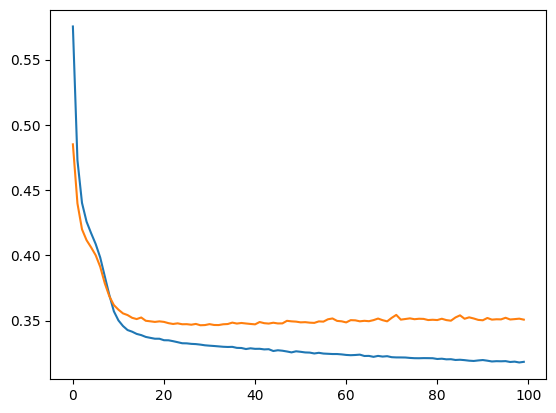

In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

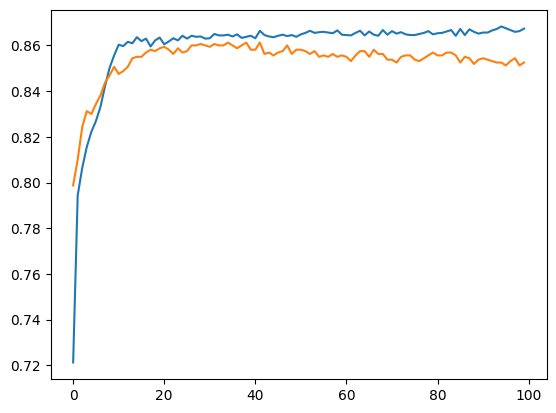

In [51]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()